In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import os
import math

In [2]:
from matplotlib.ticker import FixedLocator


def plot_heatmap(df, drift_scale, output_dir, title_map, time):
    df_drift = df[df['drift_scale'] == drift_scale]

    noise_scales = sorted(df_drift['noise_scale'].unique())
    g_min_values = sorted(df_drift['g_min'].unique())
    g_max = df_drift['g_max'].iloc[0]


    pivot_data = df_drift.pivot_table(
        index='noise_scale', 
        columns='memory_window', 
        values='norm_accuracy',
        aggfunc='mean'
    )

    memory_windows = sorted(pivot_data.columns, reverse=True)
    pivot_data = pivot_data[memory_windows]
    pivot_data = pivot_data.iloc[::-1]

    pivot_data *= 100
    plt.figure(figsize=(7.5, 6))
    ax = sns.heatmap(
        pivot_data, 
        cmap='RdYlGn', 
        cbar_kws={'label': 'Normalized Accuracy $\\mathcal{A} (\%)$'},
        xticklabels=[f'{w:.3f}' for w in memory_windows],
        yticklabels=[f'{ns:.3f}' for ns in pivot_data.index],
        linewidths=0.6,
        linecolor='black',
        vmax=99.9
    )

    plt.title(f'{title_map[time]} (Drift Scale = {drift_scale})', fontsize=16, weight='bold')
    plt.xlabel('Memory Window ($\\mu S$)', fontsize=14, weight='bold')
    plt.ylabel('Noise Scale', fontsize=14, weight='bold')
    plt.xticks(rotation=45, fontsize=10, weight='bold')
    plt.yticks(rotation=0, fontsize=10, weight='bold')
    plt.tight_layout(pad=0.5)

    # set the colorbar label size and weight
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(14)
    cbar.ax.yaxis.label.set_weight('bold')
    '''all_ticks = list(range(0, 100, 3))
    min_val = pivot_data.min().min()
    start_tick = next(t for t in all_ticks if t >= min_val)
    ticks = [t for t in all_ticks if t >= start_tick]
    cbar.set_ticks(ticks)
    cbar.locator = FixedLocator(ticks)
    cbar.update_ticks()
    labels = [f"{t}%" for t in ticks[:-1]] + ['≥99%']
    cbar.ax.set_yticklabels(labels)'''

    # set the tick label size and weight
    cbar.ax.tick_params(labelsize=10, width=1.2)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_weight('bold')

    # add hatch pattern to the cells with accuracy >= 99%
    for y in range(pivot_data.shape[0]):
        for x in range(pivot_data.shape[1]):
            val = pivot_data.iloc[y, x]
            if val >= 98.98:
                ax.add_patch(plt.Rectangle((x, y), 1, 1, 
                                        fill=False, 
                                        hatch='/////', 
                                        linewidth=0., 
                                        edgecolor='black',
                                        alpha=1.0))
    plt.savefig(output_dir)


graph/heatmap/d0.005/year.png
graph/heatmap/d0.05/year.png
graph/heatmap/d0.5/year.png
graph/heatmap/d1.0/year.png


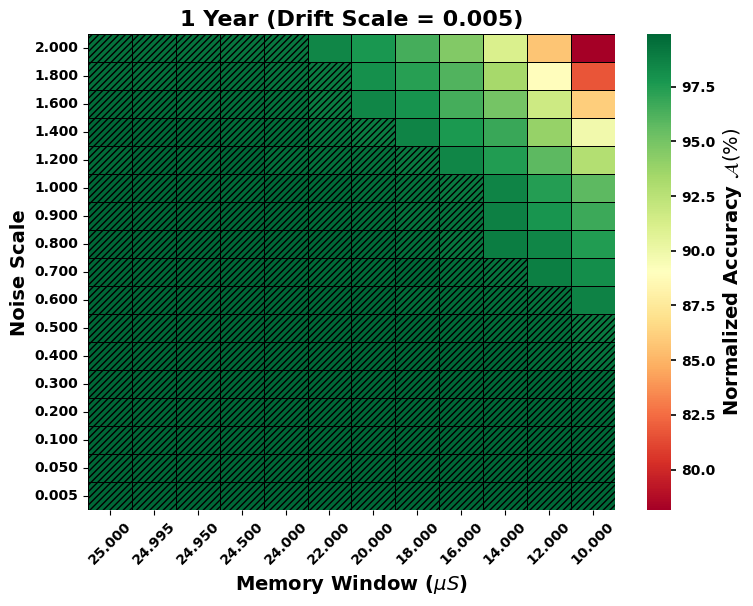

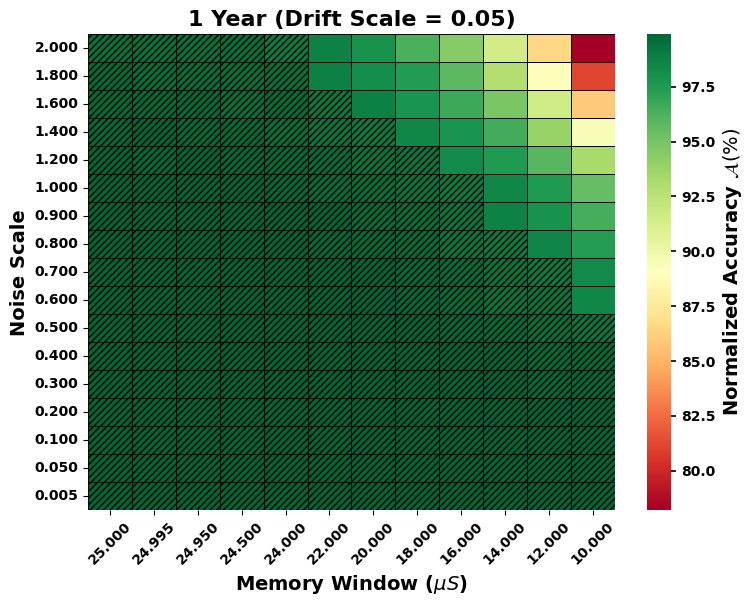

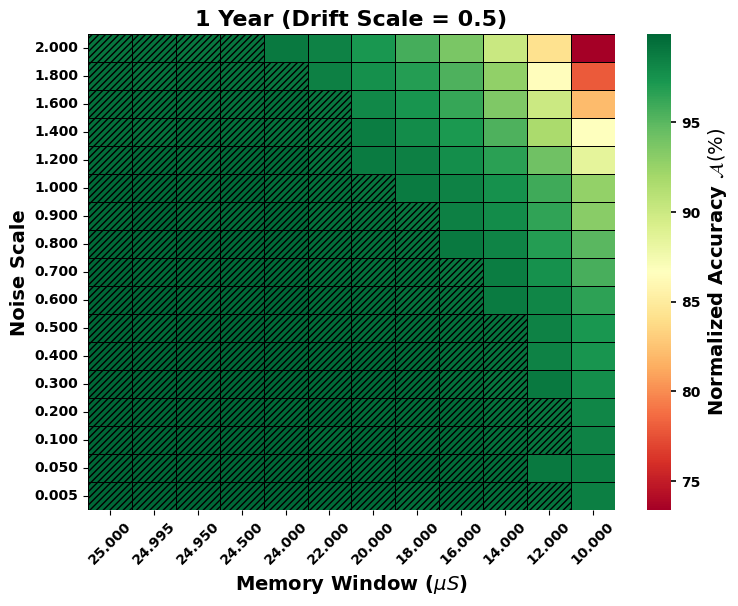

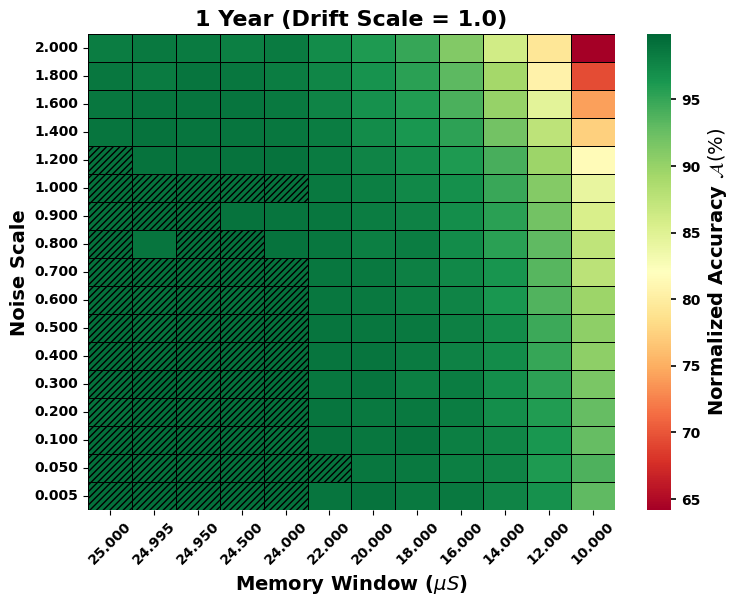

In [4]:
DATA_PATH = '../results'
TIME='year'
TITLE_MAP = {
    'second': '1 Second',
    'hour': '1 Hour',
    'day': '1 Day',
    'week': '1 Week',
    'year': '1 Year',
}
OUTPUT_DIR = 'graph/heatmap'
csv_path = os.path.join(DATA_PATH, f'inference_results_{TIME}.csv')
df = pd.read_csv(csv_path)




# get drift scales
drift_scales = sorted(df['drift_scale'].unique())

for drift_scale in drift_scales:
    output_dir = os.path.join(OUTPUT_DIR, f'd{drift_scale}/{TIME}.png')
    print(output_dir)
    plot_heatmap(df, drift_scale, output_dir, TITLE_MAP, TIME)


